In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



In [2]:
df =pd.read_csv(r"C:\Users\User\DA proj\Credit Risk Analytics & Loan Approval Optimization\datasets\credit_risk_dataset.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [3]:

df.rename(columns={'cb_person_default_on_file': 'default'},inplace=True)
df['default']=df['default'].apply(lambda x: 1 if x=='Y' else 0)
df.columns



Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income', 'default',
       'cb_person_cred_hist_length'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  default                     32581 non-null  int64  
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 3.5 MB


In [5]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
default                          0
cb_person_cred_hist_length       0
dtype: int64

OVERVIEW

In [6]:
print(f"Количество заявок: {len(df)}")
print(f"Средний доход: {df['person_income'].mean()}")
print(f"Медиана дохода: {df['person_income'].median()}")
print(f"Средний размер кредита: {df['loan_amnt'].mean()}")
print(f"Средняя процентная ставка по кредиту :{df['loan_int_rate'].mean()}")
print(f"Уровень дефолтов :{df['default'].mean()}")


Количество заявок: 32581
Средний доход: 66074.84846996715
Медиана дохода: 55000.0
Средний размер кредита: 9589.371105859243
Средняя процентная ставка по кредиту :11.011694892245037
Уровень дефолтов :0.17632976274515821


#Data quality section

In [7]:
#person_emp_length and loan_int_rate have missing values. We can assign them the mean value
emp_mean=df['person_emp_length'].mean()
loan_int_mean=df['loan_int_rate'].mean()
df['person_emp_length']=df['person_emp_length'].fillna(emp_mean)
df['loan_int_rate']=df['loan_int_rate'].fillna(loan_int_mean)
df.isna().sum()


person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
default                       0
cb_person_cred_hist_length    0
dtype: int64

In [8]:
#Drop duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,default,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.790488,9593.845632,11.016733,0.218688,0.170250,0.176765,5.811297
std,6.354100,6.201558e+04,4.088378,6322.730241,3.083040,0.413363,0.106812,0.381475,4.059030
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,0.000000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,11.011695,0.000000,0.150000,0.000000,4.000000
75%,30.000000,7.921800e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,0.000000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,1.000000,30.000000


In [10]:
#There are impossible values

df=df[df['person_age']<100]
df=df[df['person_age']>df['person_emp_length']]
df=df[df['loan_percent_income']!=0]
df.shape

(32401, 12)

In Datasets contained impossible values where a persons age was 144, years of experience exceeded age and also loan percent income equals 0. These values deleted

Univariate analys

Text(0, 0.5, 'Возраст')

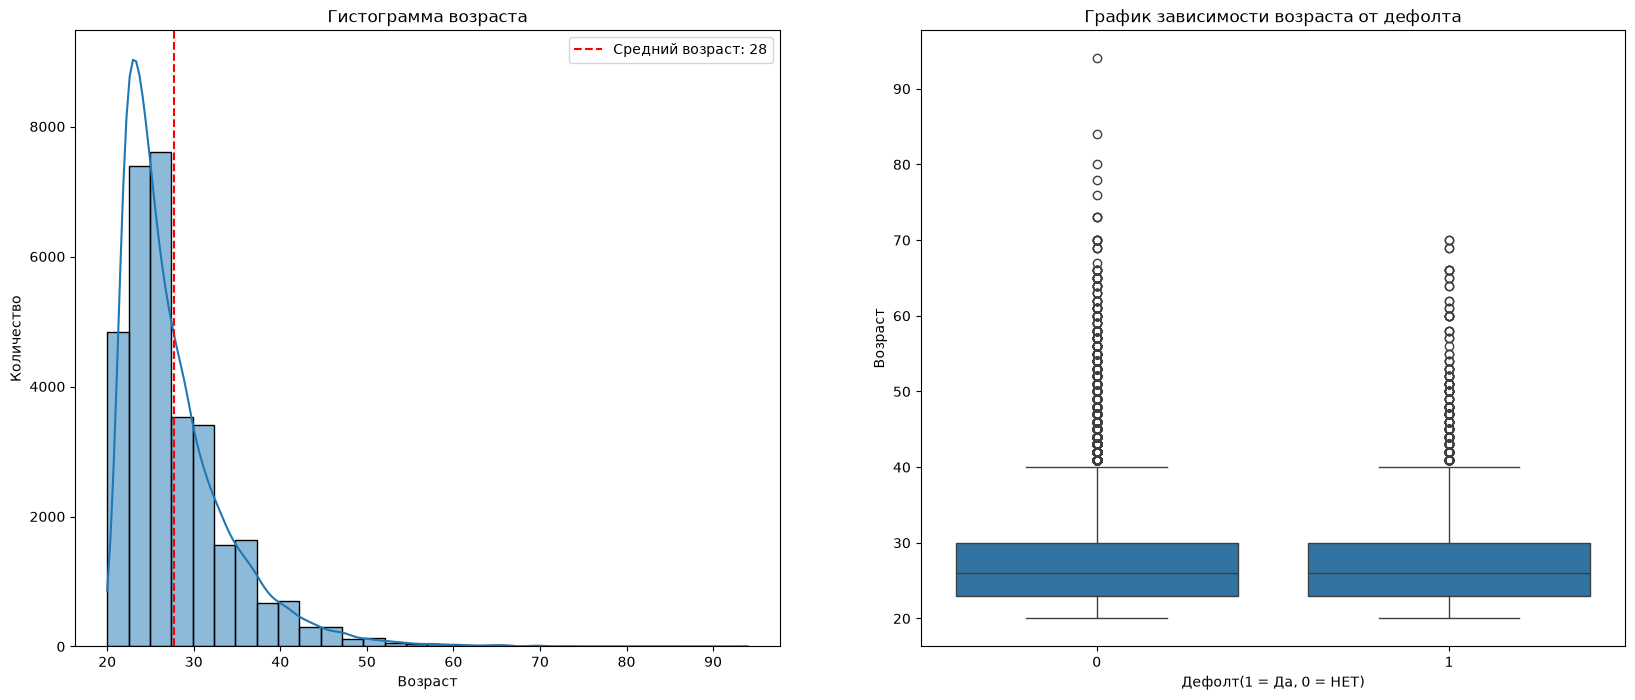

In [ ]:
#First group Applicant info(age, income, person_emp_length, person_home_ownership)
#Age
fig ,axes = plt.subplots(1,2,figsize=(20,8))

sns.histplot(
    data=df['person_age'],
    bins = 30,
    kde = True,
    ax=axes[0]
)
axes[0].set_title('Гистограмма возраста')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество')
axes[0].axvline(df['person_age'].mean(), color ='red', linestyle ='--', label=f'Средний возраст: {df['person_age'].mean():.0f}')
axes[0].legend()

sns.boxplot(
    x=df['default'],
    y=df['person_age'],
    ax=axes[1]
)
axes[1].set_title('График зависимости возраста от дефолта')
axes[1].set_xlabel('Дефолт(1 = Да, 0 = НЕТ)')
axes[1].set_ylabel('Возраст')



Graph 1 shows that the majority of people taking out loans are aged between 20 and 30.
Graph 2 shows that the age does not affect on loan(since boxes are at the same height). Also graph shows that older people(age > 40) are extremely rare fail to repay a loan.

Анализ Default Rate по квинтилям дохода:


,income_quintile,min_income,max_income,total_clients,default_rate
0,Q1 (Низкий),4000,35000,6591,43.32
1,Q2,35004,49000,6508,23.54
2,Q3,49008,63000,6366,18.25
3,Q4,63096,86000,6484,14.61
4,Q5 (Высокий),86004,1782000,6452,9.18


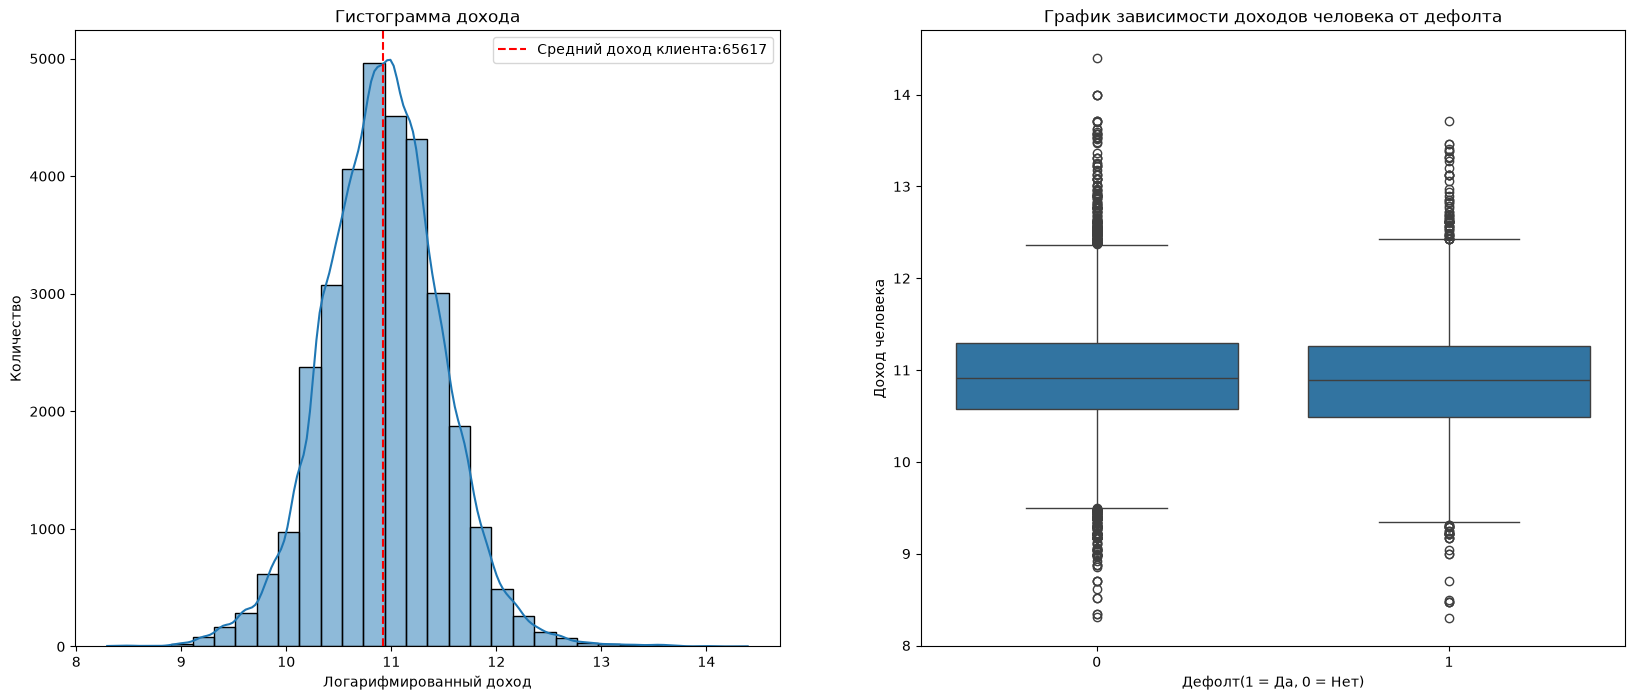

In [ ]:
#Income

fig, axes =plt.subplots(1, 2, figsize=(20,8))

sns.histplot(
    data = np.log1p(df['person_income']),
    ax =axes[0],
    bins = 30,
    kde= True,
)
axes[0].set_xlabel("Логарифмированный доход")
axes[0].set_ylabel("Количество")
axes[0].set_title("Гистограмма дохода")
axes[0].axvline( np.log1p(df['person_income']).mean(),color = 'red', linestyle = '--', label=f'Средний доход клиента:{df['person_income'].mean():.0f}')
axes[0].legend()

sns.boxplot(
    x = 'default',
    y = np.log1p(df['person_income']),
    data=df,
    ax=axes[1]
)
axes[1].set_title('График зависимости доходов человека от дефолта')
axes[1].set_xlabel('Дефолт(1 = Да, 0 = Нет)')
axes[1].set_ylabel('Доход человека')

df['income_quintile'] = pd.qcut(df['person_income'], q=5, labels=['Q1 (Низкий)', 'Q2', 'Q3', 'Q4', 'Q5 (Высокий)'])
quintile_analysis = df.groupby('income_quintile').agg(
    min_income=('person_income', 'min'),
    max_income=('person_income', 'max'),
    total_clients=('loan_status', 'count'),
    default_rate=('loan_status', 'mean')
).reset_index()

quintile_analysis['default_rate'] = (quintile_analysis['default_rate'] * 100).round(2)

print("Анализ Default Rate по квинтилям дохода:")
display(quintile_analysis)


Graph 1 shows the log distribution of people income.
Graph 2 
